# Signal Evaluation Framework  

---
### Sections
1. Setup & Configuration  
2. Data Loading  
3. Signal Generation  
4. Core Helpers  
5. Compute Base Metrics
5. Walk-Forward Optimization
6. Combinatorial Purged Cross-Validation + Probability of Backtest Overfitting
7. Expected Shortfall Curves + Drawdown Duration Distribution
8. Research Quality Score With Gates



# Setup & Configuration

In [1]:
# ==============================================================================
# --- CELL 1: SETUP & CONFIGURATION (USER ADJUSTABLE) ---
# ==============================================================================
import os
import sys
import warnings
import itertools
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

TRAIN_START = "2004-11-18"
TRAIN_END = "2018-12-31"
TEST_START = "2019-01-01"
TEST_END = "2023-12-31"

SIGNAL_MODULE_DIR = "/content/drive/My Drive/Prometheus/First cycle/"

# Trading frictions
TRANSACTION_COST_BPS = 5.0
SLIPPAGE_BPS = 2.0

# Statistical controls
NW_LAGS = 5
ES_ALPHAS =[0.01, 0.025, 0.05, 0.10]
N_CPCV_FOLDS = 8
CPCV_TEST_BLOCKS = 2
EMBARGO_DAYS = 5
MIN_OBS_PER_SPLIT = 120
WFO_TRAIN_YEARS = 5
WFO_TEST_YEARS = 1

# Research quality gates
GATE_MIN_TEST_SHARPE = 0.40
GATE_MAX_TURNOVER = 0.40
GATE_MIN_DSR = 0.50
GATE_MAX_PBO = 0.60

print("✅ Cell 1: Setup complete. Proceed to Data Loading.")

✅ Cell 1: Setup complete. Proceed to Data Loading.


# Data Loading

In [2]:
# ==============================================================================
# --- CELL 2: DATA LOADING ---
# ==============================================================================
from google.colab import drive
if not os.path.exists("/content/drive/My Drive"):
    drive.mount("/content/drive")

sys.path.insert(0, SIGNAL_MODULE_DIR)

from cycle_1_signals import (
        load_data, build_seasonal_signals, build_volume_signals, build_breadth_base_signals,
        build_macro_breadth_signals, build_rates_fx_signals, build_asym_vol_signals,
        build_fibonacci_signals, build_efficiency_noise_signals, build_overnight_intraday_signals,
        build_gap_signals, build_volatility_momentum_signals, build_autocorrelation_signals,
        build_low_rv_signals, build_high_vix_signals, build_bear_signals, build_low_vix_signals)

full_df = load_data().copy()
full_df["Ret"] = full_df["Close"].pct_change().fillna(0)
train_mask = (full_df.index >= TRAIN_START) & (full_df.index <= TRAIN_END)
test_mask = (full_df.index >= TEST_START) & (full_df.index <= TEST_END)

print(f"Data Loaded! Train rows: {train_mask.sum()} | Test rows: {test_mask.sum()}")

Mounted at /content/drive
Data Loaded! Train rows: 3553 | Test rows: 1258


# Signal Generation

In [3]:
# ==============================================================================
# --- CELL 3: SIGNAL GENERATION (USER-ADJUSTABLE) ---
# ==============================================================================
print("Generating signals…")
sea_sigs = build_seasonal_signals(full_df)
vol_sigs = build_volume_signals(full_df)
brb_sigs = build_breadth_base_signals(full_df)
mac_sigs = build_macro_breadth_signals(full_df)
rfx_sigs = build_rates_fx_signals(full_df)
asym_sigs = build_asym_vol_signals(full_df)
fib_sigs = build_fibonacci_signals(full_df)
eff_sigs = build_efficiency_noise_signals(full_df)
oni_sigs = build_overnight_intraday_signals(full_df)
gap_sigs = build_gap_signals(full_df)
vmo_sigs = build_volatility_momentum_signals(full_df)
aco_sigs = build_autocorrelation_signals(full_df)
lrv_sigs = build_low_rv_signals(full_df)
hvix_sigs = build_high_vix_signals(full_df)
bear_sigs = build_bear_signals(full_df)
lvix_sigs = build_low_vix_signals(full_df)

ALL_SIGS = {
    **sea_sigs, **vol_sigs, **brb_sigs, **mac_sigs,
    **rfx_sigs, **asym_sigs, **fib_sigs, **eff_sigs,
    **oni_sigs, **gap_sigs, **vmo_sigs, **aco_sigs,
    **lrv_sigs, **hvix_sigs, **bear_sigs, **lvix_sigs}

SIG_GROUPS = {
    "Seasonal": list(sea_sigs.keys()),
    "Volume": list(vol_sigs.keys()),
    "BreadthBase": list(brb_sigs.keys()),
    "Macro": list(mac_sigs.keys()),
    "Rates/FX": list(rfx_sigs.keys()),
    "AsymVol": list(asym_sigs.keys()),
    "Fibonacci": list(fib_sigs.keys()),
    "Efficiency": list(eff_sigs.keys()),
    "OvernightID": list(oni_sigs.keys()),
    "Gaps": list(gap_sigs.keys()),
    "VolMomentum": list(vmo_sigs.keys()),
    "AutoCorr": list(aco_sigs.keys()),
    "LowRV": list(lrv_sigs.keys()),
    "HighVIX": list(hvix_sigs.keys()),
    "Bear": list(bear_sigs.keys()),
    "LowVIX": list(lvix_sigs.keys())}

BH = pd.Series(1.0, index=full_df.index, name="Buy & Hold")

print(f"\n✅  {len(ALL_SIGS)} signals generated")
for grp, keys in SIG_GROUPS.items():
    print(f'   {grp:15s}: {keys}')

Generating signals…

✅  116 signals generated
   Seasonal       : ['Sea_01_TOM_VolExp', 'Sea_02_Jan_MeanRev', 'Sea_03_Dec_VolContr', 'Sea_04_RobustM_BBSqz', 'Sea_05_PreHol_Trend100']
   Volume         : ['Vol_01_VROC_ClimaxFade', 'Vol_02_ZThresh_Scale', 'Vol_03_PVTrend_Gap', 'Vol_04_ZMom_ExtremeRSI', 'Vol_05_CMF_Accel']
   BreadthBase    : ['BrB_01_Intraday_Mom', 'BrB_02_Thrust_BTI', 'BrB_03_MA_Align_Mom', 'BrB_04_VolWeight_Rev', 'BrB_05_ShortTerm_Rev']
   Macro          : ['Mac_01_GDX_TrendMiner', 'Mac_02_Ratio_Panic', 'Mac_03_CompBreadth', 'Mac_04_EcoDays', 'Mac_05_PurePanic', 'Mac_06_ADL_LongOnly', 'Mac_07_Corr_SPXBear', 'Mac_08_TechOutperf', 'Mac_09_SmBreadthBear', 'Mac_10_PropAdv_Ribbon', 'Mac_11_W2Rev_VVIX', 'Mac_12_CuU2_GLDBull', 'Mac_13_FiltB2_NoFri', 'Mac_14_RR10_EMA3_Long', 'Mac_15_RR50_ScaleU2']
   Rates/FX       : ['RFX_01_U10_RSI_Div_Long', 'RFX_02_U10_RealRates', 'RFX_03_U10_YieldMom', 'RFX_04_U2_YieldRev_Asym', 'RFX_05_U2_ContYield_EMA', 'RFX_06_U2_RatioTrend_Skew', 'RFX

# Core Helpers

In [4]:
# ==============================================================================
# --- CELL 4: CORE HELPERS ---
# ==============================================================================
def sanitize_signal(sig: pd.Series) -> pd.Series:
    return pd.Series(sig, index=full_df.index).fillna(0).astype(float).clip(-1, 1)

def compute_returns(sig: pd.Series, mask=None, tc_bps=TRANSACTION_COST_BPS, slip_bps=SLIPPAGE_BPS):
    s = sanitize_signal(sig)
    r_mkt = full_df["Ret"]
    gross = (s * r_mkt).fillna(0)

    prev_pos = s.shift(1).fillna(0)
    turnover = (s - prev_pos).abs()
    cost = turnover * ((tc_bps + slip_bps) / 10000.0)
    net = gross - cost

    if mask is not None:
        return gross[mask], net[mask], cost[mask], s[mask]
    return gross, net, cost, s

def max_drawdown(cum: pd.Series) -> float:
    dd = cum / cum.cummax() - 1
    return float(dd.min()) if len(dd) else 0.0

def newey_west_se_mean(ret: pd.Series, lags: int = NW_LAGS) -> float:
    x = np.asarray(ret.dropna(), dtype=float)
    n = len(x)
    if n < 3: return np.nan
    x = x - x.mean()
    lr_var = np.dot(x, x) / n
    for k in range(1, min(lags, n - 1) + 1):
        w = 1 - k / (lags + 1)
        gamma_k = np.dot(x[k:], x[:-k]) / n
        lr_var += 2 * w * gamma_k
    return float(np.sqrt(max(lr_var, 1e-18) / n))

def sharpe_stats(ret: pd.Series, nw_lags: int = NW_LAGS):
    r = ret.dropna()
    if len(r) < 10 or r.std() == 0:
        return dict(Sharpe=np.nan, Sharpe_t=np.nan, Sharpe_p=np.nan, Mean_t=np.nan, Mean_p=np.nan)

    mu, sd, n = r.mean(), r.std(), len(r)

    sr_daily = mu / sd
    sr_annual = np.sqrt(252) * sr_daily

    se_mu = newey_west_se_mean(r, lags=nw_lags)
    t_mu = mu / se_mu if se_mu > 0 else np.nan
    p_mu = 2 * (1 - norm.cdf(abs(t_mu))) if np.isfinite(t_mu) else np.nan

    se_sr_daily = np.sqrt((1 + 0.5 * sr_daily**2) / max(n - 1, 1))
    t_sr = sr_daily / se_sr_daily if se_sr_daily > 0 else np.nan
    p_sr = 2 * (1 - norm.cdf(abs(t_sr))) if np.isfinite(t_sr) else np.nan

    return dict(Sharpe=sr_annual, Sharpe_t=t_sr, Sharpe_p=p_sr, Mean_t=t_mu, Mean_p=p_mu)

def deflated_sharpe_ratio(sr_annual: float, n_obs: int, n_trials: int, skewness: float, ex_kurt: float) -> float:
    if not np.isfinite(sr_annual) or n_obs < 30: return np.nan

    sr_daily = sr_annual / np.sqrt(252)

    z = norm.ppf(1 - 1 / max(n_trials, 2))
    sr_star_daily = z * np.sqrt(1 / max(n_obs - 1, 1))

    numer = 1 - skewness * sr_daily + ((ex_kurt - 1) / 4.0) * (sr_daily**2)
    se_sr_daily = np.sqrt(max(numer, 1e-10) / max(n_obs - 1, 1))

    z_score = (sr_daily - sr_star_daily) / max(se_sr_daily, 1e-12)
    return float(norm.cdf(z_score))

print("✅ Cell 4: Core math helper functions loaded.")

✅ Cell 4: Core math helper functions loaded.


# Compute Base Metrics

In [5]:
# ==============================================================================
# --- CELL 5: COMPUTE BASE METRICS ---
# ==============================================================================
def summary_metrics(sig: pd.Series, mask=None):
    gross, net, cost, s = compute_returns(sig, mask)
    r = net.fillna(0)

    if len(r) < 10 or r.std() == 0:
        return {"NetSharpe": 0, "Turnover": 0, "DSR": 0, "NW_Mean_t": 0, "ES_5": 0}

    sh = sharpe_stats(r)
    turnover = s.diff().abs().fillna(0).mean()

    var_5 = np.quantile(r, 0.05)
    es_5 = r[r <= var_5].mean() if len(r[r <= var_5]) else var_5

    dsr = deflated_sharpe_ratio(
        sr_annual=sh["Sharpe"], n_obs=len(r), n_trials=max(len(ALL_SIGS), 2),
        skewness=float(skew(r, bias=False)), ex_kurt=float(kurtosis(r, fisher=False, bias=False)))

    return {
        "NetSharpe": round(float(sh["Sharpe"]), 4),
        "NW_Mean_t": round(float(sh["Mean_t"]), 4),
        "Turnover": round(float(turnover), 4),
        "ES_5": round(float(es_5 * 100), 3),
        "DSR": round(float(dsr), 4)}

base_metrics = {}
print("Computing standard Train/Test metrics for all signals...")
for name, sig in ALL_SIGS.items():
    tr_m = summary_metrics(sig, train_mask)
    te_m = summary_metrics(sig, test_mask)
    base_metrics[name] = {"Train": tr_m, "Test": te_m}

# Display standard metrics instantly
df_base = pd.DataFrame([{
    "Signal": k,
    "Train_Sharpe": v["Train"]["NetSharpe"],
    "Test_Sharpe": v["Test"]["NetSharpe"],
    "Test_DSR": v["Test"]["DSR"]}

for k, v in base_metrics.items()]).set_index("Signal")

display(df_base.style.background_gradient(cmap="RdYlGn"))

Computing standard Train/Test metrics for all signals...


,Train_Sharpe,Test_Sharpe,Test_DSR
Signal,,,
Sea_01_TOM_VolExp,0.353500,0.348700,0.053300
Sea_02_Jan_MeanRev,0.230400,0.701300,0.083900
Sea_03_Dec_VolContr,0.417700,1.364700,0.787600
Sea_04_RobustM_BBSqz,0.469000,1.065000,0.498800
Sea_05_PreHol_Trend100,0.450400,0.165100,0.024400
Vol_01_VROC_ClimaxFade,-0.171700,0.564400,0.122800
Vol_02_ZThresh_Scale,-0.132000,0.164600,0.022100
Vol_03_PVTrend_Gap,0.413300,0.461300,0.062400
Vol_04_ZMom_ExtremeRSI,-0.224400,-0.462300,0.000300


# Walk-Forward Optimization

In [6]:
# ==============================================================================
# --- CELL 6: WALK-FORWARD OPTIMIZATION ---
# ==============================================================================
print("Running Walk-Forward Optimization (WFO)...")
def walk_forward_diagnostics(sig: pd.Series):
    years = sorted(pd.Index(full_df.index.year).unique())
    splits =[]
    for i in range(0, len(years) - (WFO_TRAIN_YEARS + WFO_TEST_YEARS) + 1):
        tr_years = years[i:i + WFO_TRAIN_YEARS]
        te_years = years[i + WFO_TRAIN_YEARS:i + WFO_TRAIN_YEARS + WFO_TEST_YEARS]
        tr_mask = pd.Index(full_df.index.year).isin(tr_years)
        te_mask = pd.Index(full_df.index.year).isin(te_years)
        splits.append((tr_mask, te_mask))

    oos_sharpes =[]
    for tr_mask, te_mask in splits:
        te_sr = summary_metrics(sig, te_mask)["NetSharpe"]
        if not np.isnan(te_sr): oos_sharpes.append(te_sr)

    return {
        "WFO_MedianTestSharpe": np.median(oos_sharpes) if oos_sharpes else np.nan,
        "WFO_Positive_Share": np.mean(np.array(oos_sharpes) > 0) if oos_sharpes else np.nan}

wfo_results = {name: walk_forward_diagnostics(sig) for name, sig in ALL_SIGS.items()}
display(pd.DataFrame(wfo_results).T.style.background_gradient(cmap="RdYlGn"))

Running Walk-Forward Optimization (WFO)...


,WFO_MedianTestSharpe,WFO_Positive_Share
Sea_01_TOM_VolExp,0.443100,0.533333
Sea_02_Jan_MeanRev,0.220400,0.533333
Sea_03_Dec_VolContr,1.195500,0.666667
Sea_04_RobustM_BBSqz,0.761700,0.666667
Sea_05_PreHol_Trend100,0.094100,0.600000
Vol_01_VROC_ClimaxFade,-0.433200,0.466667
Vol_02_ZThresh_Scale,-0.202500,0.400000
Vol_03_PVTrend_Gap,0.092600,0.533333
Vol_04_ZMom_ExtremeRSI,-0.549100,0.266667
Vol_05_CMF_Accel,-0.313100,0.333333


# Combinatorial Purged Cross-Validation + Probability of Backtest Overfitting

In [7]:
# ==============================================================================
# --- CELL 7: CPCV & PROBABILITY OF BACKTEST OVERFITTING ---
# ==============================================================================
print("Running Combinatorial Purged Cross-Validation (CPCV)...")
def cpcv_splits(index):
    n = len(index)
    fold_sizes =[n // N_CPCV_FOLDS] * N_CPCV_FOLDS
    for i in range(n % N_CPCV_FOLDS): fold_sizes[i] += 1
    boundaries =[]
    s = 0
    for sz in fold_sizes:
        boundaries.append((s, s + sz))
        s += sz

    combos = list(itertools.combinations(range(N_CPCV_FOLDS), CPCV_TEST_BLOCKS))
    for cmb in combos:
        test_mask = np.zeros(n, dtype=bool)
        for f in cmb:
            a, b = boundaries[f]
            test_mask[a:b] = True

        train_mask = ~test_mask
        true_idx = np.where(train_mask)[0]
        if len(true_idx) > 0:
            min_i, max_i = true_idx.min(), true_idx.max()
            train_mask[max(0, min_i - EMBARGO_DAYS) : min(n, max_i + EMBARGO_DAYS + 1)] = False

        yield train_mask, test_mask

split_data = list(cpcv_splits(full_df.index))
names = list(ALL_SIGS.keys())

n_splits = len(split_data)
n_signals = len(names)

is_matrix = np.zeros((n_signals, n_splits))
oos_matrix = np.zeros((n_signals, n_splits))

print(f"Evaluating {n_splits} CPCV splits for {n_signals} signals (this may take a moment)...")
for s, (tr_mask, te_mask) in enumerate(split_data):
    for i, nm in enumerate(names):
        is_matrix[i, s] = summary_metrics(ALL_SIGS[nm], tr_mask)["NetSharpe"]
        oos_matrix[i, s] = summary_metrics(ALL_SIGS[nm], te_mask)["NetSharpe"]

print("Computing Global & Signal-Level PBO...")
global_logits =[]
cpcv_results = {}

for s in range(n_splits):
    tr_srs = is_matrix[:, s]
    te_srs = oos_matrix[:, s]

    if np.all(np.isnan(tr_srs)) or np.all(np.isnan(te_srs)): continue

    best_idx = np.nanargmax(tr_srs)
    oos_rank = pd.Series(te_srs).rank(pct=True).iloc[best_idx]
    oos_rank = float(np.clip(oos_rank, 1e-6, 1 - 1e-6))
    global_logits.append(math.log(oos_rank / (1 - oos_rank)))

PBO_GLOBAL = float(np.mean(np.array(global_logits) < 0)) if global_logits else np.nan
print(f"🌍 Global Probability of Backtest Overfitting (PBO): {PBO_GLOBAL:.4f}\n")

for i, nm in enumerate(names):
    te_srs_signal = oos_matrix[i, :]

    sig_logits =[]
    for s in range(n_splits):
        te_srs_split = oos_matrix[:, s]
        if np.all(np.isnan(te_srs_split)): continue

        oos_rank = pd.Series(te_srs_split).rank(pct=True).iloc[i]
        oos_rank = float(np.clip(oos_rank, 1e-6, 1 - 1e-6))
        sig_logits.append(math.log(oos_rank / (1 - oos_rank)))

    sig_pbo = float(np.mean(np.array(sig_logits) < 0)) if sig_logits else np.nan

    cpcv_results[nm] = {
        "CPCV_MedianTestSharpe": float(np.nanmedian(te_srs_signal)),
        "CPCV_Positive_Share": float(np.nanmean(te_srs_signal > 0)),
        "Signal_PBO": round(sig_pbo, 4)}

cpcv_df = pd.DataFrame(cpcv_results).T

display(cpcv_df.style.background_gradient(cmap="RdYlGn", subset=["CPCV_MedianTestSharpe", "CPCV_Positive_Share"])
               .background_gradient(cmap="RdYlGn_r", subset=["Signal_PBO"]))

Running Combinatorial Purged Cross-Validation (CPCV)...
Evaluating 28 CPCV splits for 116 signals (this may take a moment)...
Computing Global & Signal-Level PBO...
🌍 Global Probability of Backtest Overfitting (PBO): 0.5714



,CPCV_MedianTestSharpe,CPCV_Positive_Share,Signal_PBO
Sea_01_TOM_VolExp,0.247800,0.785714,0.571400
Sea_02_Jan_MeanRev,0.418250,0.857143,0.428600
Sea_03_Dec_VolContr,0.644600,0.892857,0.285700
Sea_04_RobustM_BBSqz,0.615000,0.928571,0.107100
Sea_05_PreHol_Trend100,0.374300,0.892857,0.428600
Vol_01_VROC_ClimaxFade,0.020000,0.535714,0.642900
Vol_02_ZThresh_Scale,-0.038200,0.500000,0.857100
Vol_03_PVTrend_Gap,0.429850,0.928571,0.285700
Vol_04_ZMom_ExtremeRSI,-0.327900,0.285714,0.964300
Vol_05_CMF_Accel,-0.303800,0.357143,0.892900


# Expected Shortfall Curves + Drawdown Duration Distribution

Plotting Expected Shortfall Curves for ALL Signals (Grouped by Family)...


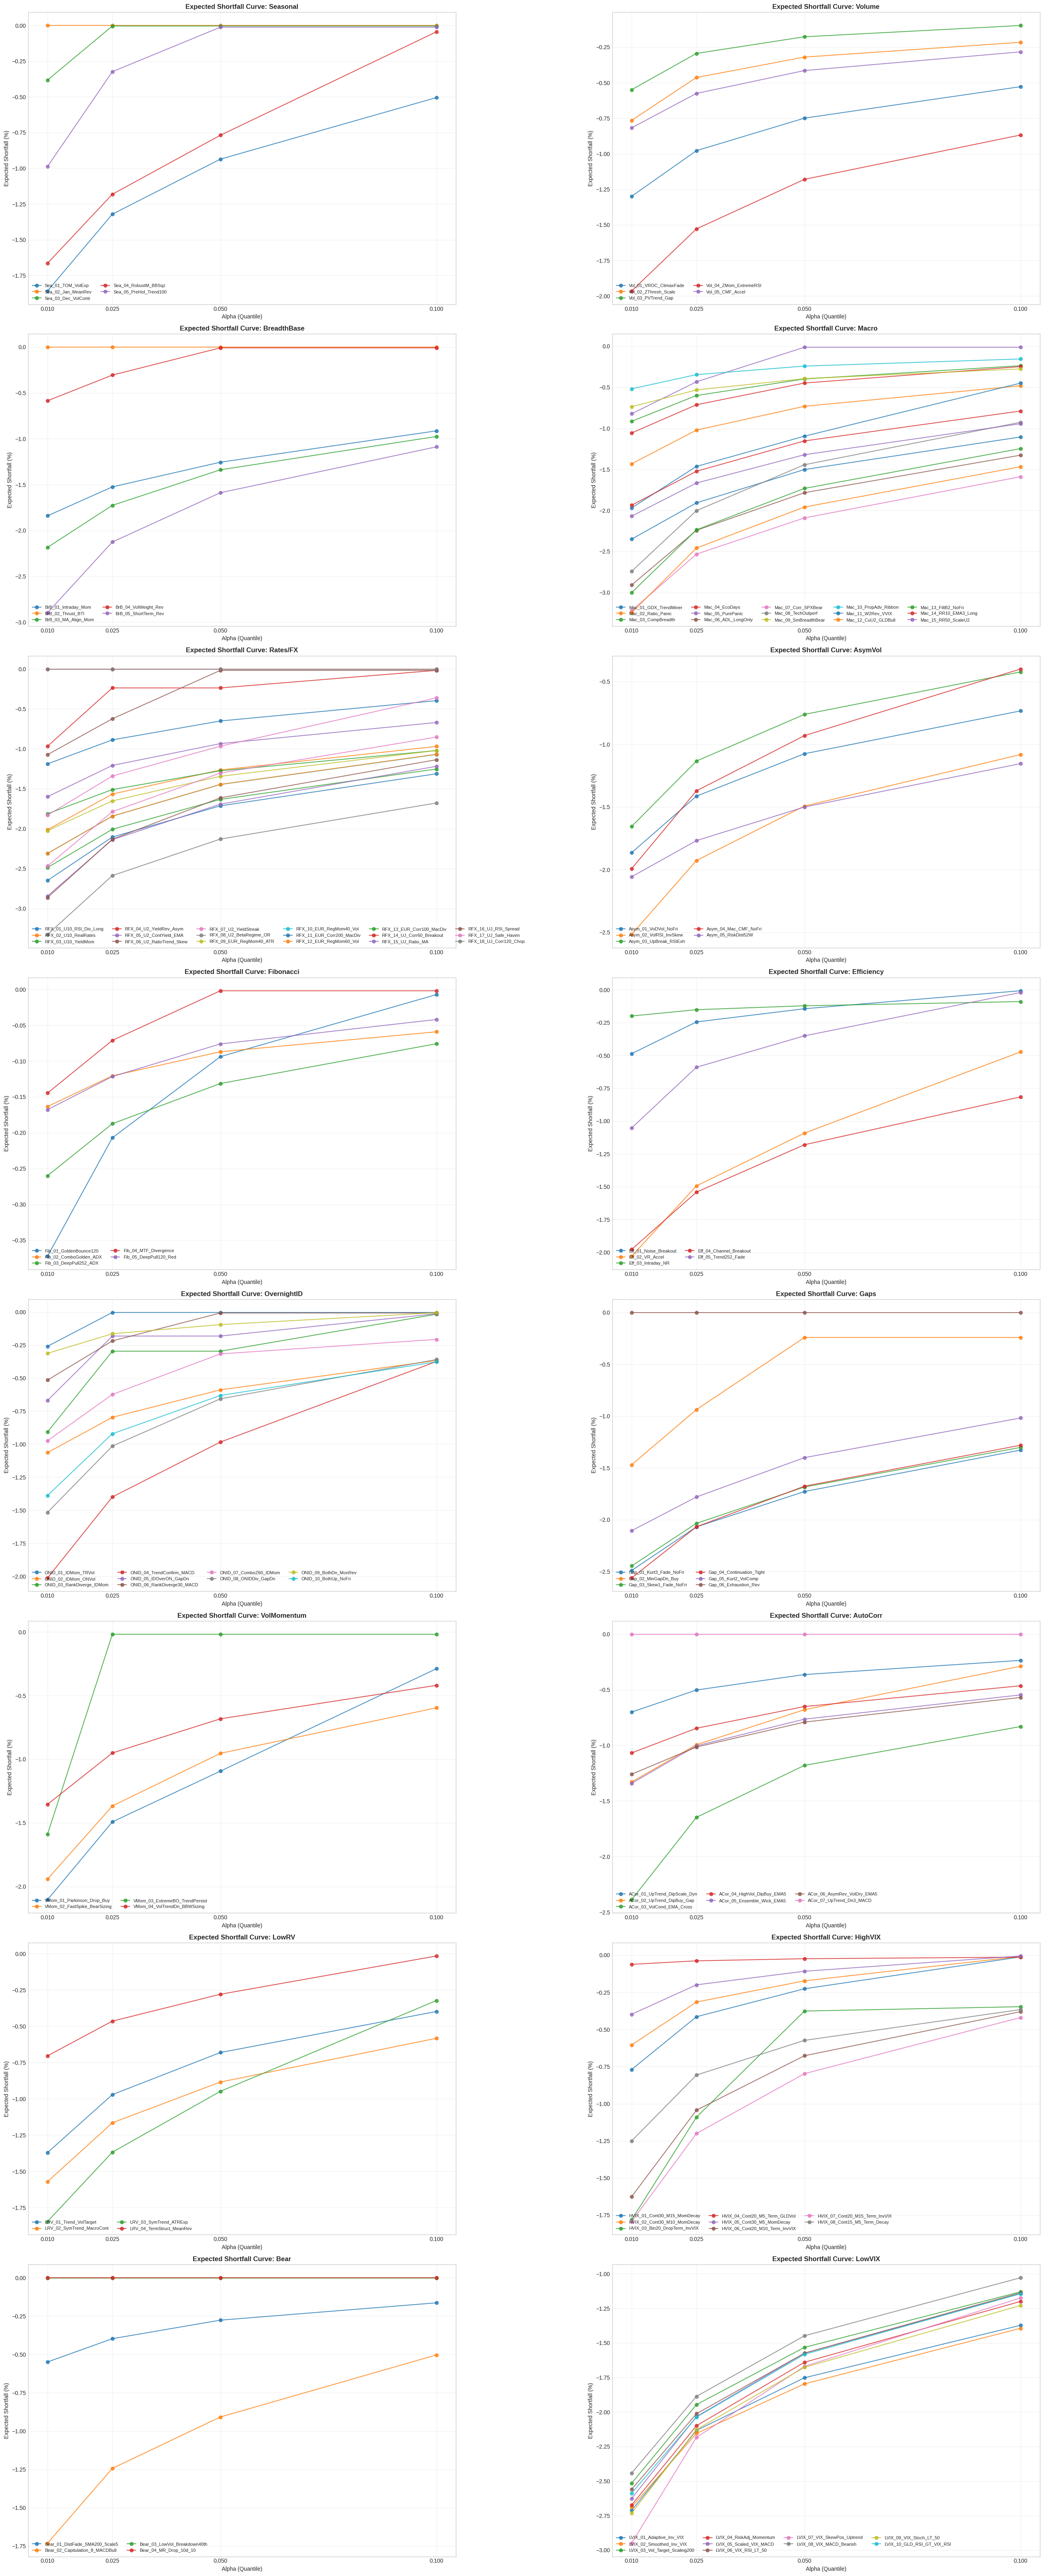

✅ Expected Shortfall plotting complete.


In [11]:
# ==============================================================================
# --- CELL 8: EXPECTED SHORTFALL CURVES ---
# ==============================================================================
print("Plotting Expected Shortfall Curves for ALL Signals (Grouped by Family)...")

valid_groups = {grp: keys for grp, keys in SIG_GROUPS.items() if any(k in ALL_SIGS for k in keys)}
n_groups = len(valid_groups)

cols = 2
rows = math.ceil(n_groups / cols)

fig, axes = plt.subplots(rows, cols, figsize=(26, 8 * rows))
axes = axes.flatten()

for idx, (grp, keys) in enumerate(valid_groups.items()):
    ax = axes[idx]
    plot_count = 0

    for name in keys:
        if name not in ALL_SIGS:
            continue

        _, net, _, _ = compute_returns(ALL_SIGS[name], test_mask)
        r = net.fillna(0)

        es_vals = []
        for a in ES_ALPHAS:
            tail = r[r <= np.quantile(r, a)]
            es = np.mean(tail) * 100 if len(tail) > 0 else 0.0
            es_vals.append(es)

        ax.plot(ES_ALPHAS, es_vals, marker="o", lw=1.5, alpha=0.8, label=name)
        plot_count += 1

    ax.set_title(f"Expected Shortfall Curve: {grp}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Alpha (Quantile)")
    ax.set_ylabel("Expected Shortfall (%)")
    ax.set_xticks(ES_ALPHAS)

    if plot_count > 0:
        ax.legend(fontsize=8, ncol=max(1, math.ceil(plot_count / 3)), loc="lower left")

    ax.grid(True, alpha=0.3)

for i in range(n_groups, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

print("✅ Expected Shortfall plotting complete.")

# Research Quality Score With Gates

In [13]:
# ==============================================================================
# --- CELL 9: FINAL SCORECARD AND GATING ---
# ==============================================================================
print("Assembling Final Research Scorecard...")
rows = []
for name in ALL_SIGS.keys():
    te_m = base_metrics[name]["Test"]
    w_m = wfo_results[name]
    c_m = cpcv_results[name]

    hard_pass = (
        (te_m["NetSharpe"] >= GATE_MIN_TEST_SHARPE) and
        (te_m["Turnover"] <= GATE_MAX_TURNOVER) and
        (te_m["DSR"] >= GATE_MIN_DSR) and
        (np.isnan(PBO_GLOBAL) or PBO_GLOBAL <= GATE_MAX_PBO))

    score = (
        25 * np.clip((te_m["NetSharpe"] + 1) / 2, 0, 1) +
        15 * np.clip(te_m["DSR"], 0, 1) +
        15 * np.clip(w_m["WFO_Positive_Share"], 0, 1) +
        15 * np.clip(c_m["CPCV_Positive_Share"], 0, 1) +
        15 * np.clip(1 - te_m["Turnover"] / max(GATE_MAX_TURNOVER, 1e-6), 0, 1) +
        15 * np.clip(1 - (max(PBO_GLOBAL, 0) if np.isfinite(PBO_GLOBAL) else 0.5), 0, 1))

    rows.append({
        "Signal": name,
        "TrainNetSharpe": base_metrics[name]["Train"]["NetSharpe"],
        "TestNetSharpe": te_m["NetSharpe"],
        "TestNW_t": te_m["NW_Mean_t"],
        "TestTurnover": te_m["Turnover"],
        "TestES5": te_m["ES_5"],
        "DSR": te_m["DSR"],
        "WFO_MedianSharpe": w_m["WFO_MedianTestSharpe"],
        "CPCV_MedianSharpe": c_m["CPCV_MedianTestSharpe"],
        "HardGatesPass": hard_pass,
        "QualityScore": round(score, 2)})

scorecard = pd.DataFrame(rows).set_index("Signal")
print("\n✅ Final Report Generated. Displaying top candidates:")
display(scorecard.sort_values(["HardGatesPass", "QualityScore"], ascending=[False, False])
        .style.background_gradient(subset=["TestNetSharpe", "QualityScore", "DSR"], cmap="RdYlGn")
        .background_gradient(subset=["TestTurnover"], cmap="RdYlGn_r"))

Assembling Final Research Scorecard...

✅ Final Report Generated. Displaying top candidates:


,TrainNetSharpe,TestNetSharpe,TestNW_t,TestTurnover,TestES5,DSR,WFO_MedianSharpe,CPCV_MedianSharpe,HardGatesPass,QualityScore
Signal,,,,,,,,,,
Sea_03_Dec_VolContr,0.417700,1.364700,2.585300,0.007200,-0.004000,0.787600,1.195500,0.644600,True,81.370000
Fib_01_GoldenBounce120,0.211600,1.344500,3.094800,0.054600,-0.094000,0.786600,0.526100,0.433550,True,78.570000
ONID_07_ComboZ60_IDMom,0.308100,1.255600,3.243300,0.083900,-0.317000,0.684300,0.778400,0.627500,True,76.940000
BrB_04_VolWeight_Rev,0.113200,1.204900,2.406900,0.014200,-0.008000,0.668100,0.000000,0.345000,True,75.240000
RFX_18_UJ_Corr120_Chop,0.409200,1.119100,1.572300,0.006400,-0.002000,0.565600,0.000000,0.523050,True,74.070000
RFX_01_U10_RSI_Div_Long,0.151900,1.172700,2.492000,0.084200,-0.651000,0.598400,0.583800,0.384900,True,71.350000
Sea_04_RobustM_BBSqz,0.469000,1.065000,2.650100,0.039700,-0.769000,0.498800,0.761700,0.615000,False,76.350000
Mac_04_EcoDays,0.335300,0.967100,2.609200,0.070600,-0.448000,0.405100,0.793500,0.465800,False,73.910000
ONID_01_IDMom_TRVol,0.433300,0.876800,1.581900,0.017800,-0.003000,0.312500,0.126000,0.572450,False,71.370000
